# DimeNet++ on 200 Biomolecules (data0000.aselmdb)

Matched to the `simpleGNN` setup so the loss curves are directly comparable:

- Same shard: `data0000.aselmdb`
- Same filter: biomolecules only
- Same cap: 200 molecules (simpleGNN used 100 — this one uses 200, easy to change)
- Same 80/20 split, batch size, MSE loss, Adam @ 1e-3, 50 epochs
- Tracks both loss (MSE) and MAE (eV) per epoch, like simpleGNN did

Only architectural variable changed: SchNet-style distance GNN → DimeNet++ with angles.

In [ ]:
import torch
print("Torch:", torch.__version__)

from fairchem.core.datasets import AseDBDataset
ds = AseDBDataset({"src": "/content/data/data0000.aselmdb"})
print(f"Shard has {len(ds)} molecules")

atoms = ds.get_atoms(1)  # idx 1 was biomolecules in your earlier output
print(f"Atoms: {atoms}")
print(f"data_id: {atoms.info.get('data_id')}")
print(f"gap: {atoms.info.get('homo_lumo_gap')}")

Torch: 2.5.0+cu121
Shard has 49835 molecules
Atoms: Atoms(symbols='OHCOCH6', pbc=False, calculator=SinglePointCalculator(...))
data_id: biomolecules
gap: [7.1457916]


In [ ]:
import torch
print("Torch:", torch.__version__)

from fairchem.core.datasets import AseDBDataset
print("fairchem OK")

Torch: 2.5.0+cu121
fairchem OK


In [ ]:
import torch
print("Torch:", torch.__version__)
from torch_cluster import radius_graph
print("torch_cluster OK")

Torch: 2.5.0+cu121
torch_cluster OK


In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CUDA available: True
Device: Tesla T4


In [ ]:

!ls /content/data/

data0000.aselmdb


In [ ]:
from extract_simple import *

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import DimeNetPlusPlus
from torch.utils.data import random_split

In [ ]:
# Same data-loading entry points simpleGNN uses
import sys
sys.path.insert(0, '/content')

from extract_simple import *

my_path = '/content/data'
MAX_MOLS = 2000

files_list = find_files(my_path)
raw_dataset = process_file(files_list, molecule_type='biomolecules', max_molecules=MAX_MOLS)
print(f"Loaded {len(raw_dataset)} biomolecules")

Loaded 2000 biomolecules


In [ ]:
# Build PyG Data objects (z, pos, y) for DimeNet++
import numpy as np
import torch
from torch_geometric.data import Data

def mol_to_data(z, pos, y):
    z = torch.tensor(z, dtype=torch.long)
    pos = torch.tensor(pos, dtype=torch.float)
    y = torch.tensor(y, dtype=torch.float)
    return Data(z=z, pos=pos, y=y)

torch_data = []
for row in raw_dataset:
    atoms = row[0]  # process_file returns (N, 1) object array; unwrap
    z = atoms.get_atomic_numbers()
    pos = atoms.get_positions()
    gap = atoms.info['homo_lumo_gap']
    if isinstance(gap, (list, tuple, np.ndarray)):
        gap = float(np.mean(gap))
    torch_data.append(mol_to_data(z, pos, gap))

print(f"Built {len(torch_data)} PyG Data objects")
print(f"Example: {torch_data[0]}")

Built 2000 PyG Data objects
Example: Data(y=7.145791530609131, pos=[11, 3], z=[11])


In [ ]:
# Split 80/20 with fixed seed, create loaders
from torch.utils.data import random_split
from torch_geometric.loader import DataLoader

train_size = int(0.8 * len(torch_data))
val_size = len(torch_data) - train_size
train_dataset, val_dataset = random_split(
    torch_data, [train_size, val_size],
    generator=torch.Generator().manual_seed(42),
)
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

Train: 1600, Val: 400


In [ ]:
# DimeNet++ model (sized down for 200-sample dataset)
import torch.nn as nn
from torch_geometric.nn import DimeNetPlusPlus

class DimeNetPPModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.dimenet = DimeNetPlusPlus(
            hidden_channels=64,
            out_channels=1,
            num_blocks=3,
            int_emb_size=64,
            basis_emb_size=8,
            out_emb_channels=128,
            num_spherical=7,
            num_radial=6,
            cutoff=5.0,
            envelope_exponent=5,
            num_before_skip=1,
            num_after_skip=2,
            num_output_layers=3,
        )

    def forward(self, data):
        return self.dimenet(data.z, data.pos, batch=data.batch).view(-1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DimeNetPPModel().to(device)
print(f"Device: {device}")
print(f"Params: {sum(p.numel() for p in model.parameters()):,}")

Device: cuda
Params: 392,966


In [ ]:
# Training loop — matches simpleGNN's setup for fair comparison
import torch.optim as optim
from tqdm import tqdm

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train_model(model, train_loader, val_loader, loss_fn, optimizer,
                epochs=50, print_every=5, device='cpu'):
    history = {'train_loss': [], 'val_loss': [], 'train_mae': [], 'val_mae': []}
    model = model.to(device)

    for epoch in tqdm(range(epochs), desc='Training'):
        model.train()
        ep_tl, ep_tm = 0.0, 0.0
        for batch in train_loader:
            batch = batch.to(device)
            preds = model(batch)
            targets = batch.y.reshape(-1).float()
            loss = loss_fn(preds, targets)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            ep_tl += loss.item()
            ep_tm += torch.mean(torch.abs(preds - targets)).item()
        avg_tl = ep_tl / len(train_loader)
        avg_tm = ep_tm / len(train_loader)

        model.eval()
        ep_vl, ep_vm = 0.0, 0.0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                preds = model(batch)
                targets = batch.y.reshape(-1).float()
                ep_vl += loss_fn(preds, targets).item()
                ep_vm += torch.mean(torch.abs(preds - targets)).item()
        avg_vl = ep_vl / len(val_loader)
        avg_vm = ep_vm / len(val_loader)

        history['train_loss'].append(avg_tl)
        history['val_loss'].append(avg_vl)
        history['train_mae'].append(avg_tm)
        history['val_mae'].append(avg_vm)

        if (epoch + 1) % print_every == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {avg_tl:.4f} | Val Loss: {avg_vl:.4f} | "
                  f"Train MAE: {avg_tm:.4f} | Val MAE: {avg_vm:.4f}")

    return history

history = train_model(model, train_loader, val_loader, loss_fn, optimizer,
                      epochs=100, print_every=1, device=device)

Training:   1%|          | 1/100 [00:11<19:43, 11.95s/it]

Epoch   1/100 | Train Loss: 33.0580 | Val Loss: 16.8224 | Train MAE: 4.8856 | Val MAE: 3.3693


Training:   2%|▏         | 2/100 [00:23<19:12, 11.76s/it]

Epoch   2/100 | Train Loss: 17.5890 | Val Loss: 13.9211 | Train MAE: 3.3470 | Val MAE: 2.9475


Training:   3%|▎         | 3/100 [00:35<18:55, 11.71s/it]

...

Epoch  98/100 | Train Loss: 0.2921 | Val Loss: 6.0358 | Train MAE: 0.4096 | Val MAE: 1.8781


Training:  99%|█████████▉| 99/100 [19:40<00:11, 11.91s/it]

Epoch  99/100 | Train Loss: 0.2559 | Val Loss: 5.7786 | Train MAE: 0.3715 | Val MAE: 1.8112


Training: 100%|██████████| 100/100 [19:52<00:00, 11.92s/it]

Epoch 100/100 | Train Loss: 0.2329 | Val Loss: 5.7767 | Train MAE: 0.3579 | Val MAE: 1.8104


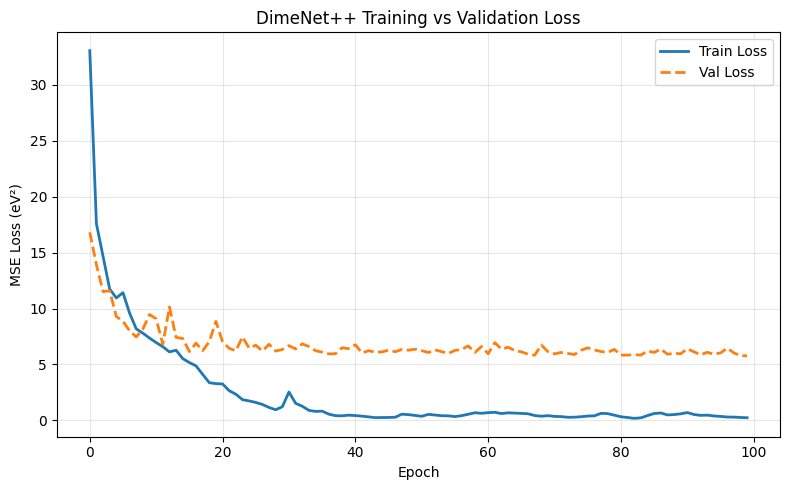

In [ ]:
def plot_losses(history, title='DimeNet++ Training vs Validation Loss'):
    plt.figure(figsize=(8, 5))
    plt.plot(history['train_loss'], label='Train Loss', linewidth=2)
    plt.plot(history['val_loss'],   label='Val Loss',   linewidth=2, linestyle='--')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss (eV²)')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_losses(history)

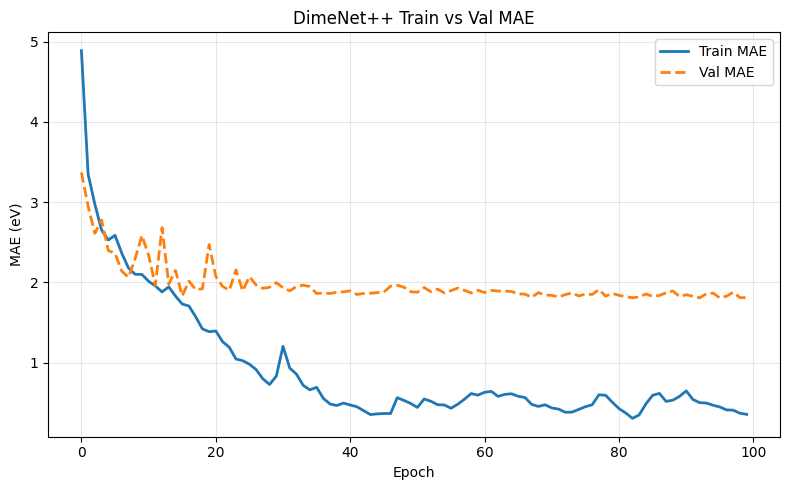

In [ ]:
# Optional: MAE plot (directly interpretable in eV, matches simpleGNN's MAE tracking)
plt.figure(figsize=(8, 5))
plt.plot(history['train_mae'], label='Train MAE', linewidth=2)
plt.plot(history['val_mae'],   label='Val MAE',   linewidth=2, linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('MAE (eV)')
plt.title('DimeNet++ Train vs Val MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()